# About Dataset
**Description:**
Breast cancer is the most common cancer amongst women in the world. It accounts for 25% of all cancer cases, and affected over 2.1 Million people in 2015 alone. It starts when cells in the breast begin to grow out of control. These cells usually form tumors that can be seen via X-ray or felt as lumps in the breast area.

The key challenges against it’s detection is how to classify tumors into malignant (cancerous) or benign(non cancerous). We ask you to complete the analysis of classifying these tumors using machine learning (with SVMs) and the Breast Cancer Wisconsin (Diagnostic) Dataset.   

        - radius (mean of distances from center to points on the perimeter)
        - texture (standard deviation of gray-scale values)
        - perimeter
        - area
        - smoothness (local variation in radius lengths)
        - compactness (perimeter^2 / area - 1.0)
        - concavity (severity of concave portions of the contour)
        - concave points (number of concave portions of the contour)
        - symmetry
        - fractal dimension ("coastline approximation" - 1)

# Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
from sklearn.preprocessing import StandardScaler
!pip install xgboost
!pip install lightgbm


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [5]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost.sklearn import XGBClassifier
from lightgbm import LGBMClassifier

In [6]:
import tensorflow as tf
from tensorflow import keras
tf.random.set_seed(3)

In [7]:
from sklearn.metrics  import f1_score, accuracy_score, classification_report, confusion_matrix, recall_score, precision_score

# Reading the dataset

In [8]:
import pandas as pd

data = pd.read_csv(r"C:\Users\mohiv\Downloads\breast-cancer.csv")
data


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [9]:
data.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [11]:
data.diagnosis.value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

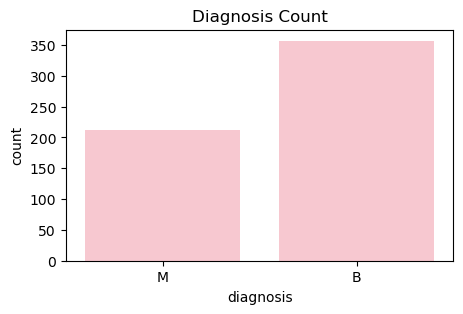

In [12]:
# Count of Diagnosis (M = Malignant, B = Benign)
plt.figure(figsize=(5,3))
sns.countplot(x='diagnosis', data=data, color='pink')
plt.title('Diagnosis Count')
plt.show()


In [13]:
data.groupby(data.diagnosis).mean()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,,,,,,,,,,,,,,,,,,,,,
B,2.654382e+07,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,...,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442
M,3.681805e+07,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,...,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530


In [14]:
data.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [15]:
data.duplicated().sum()

0

In [16]:
data.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


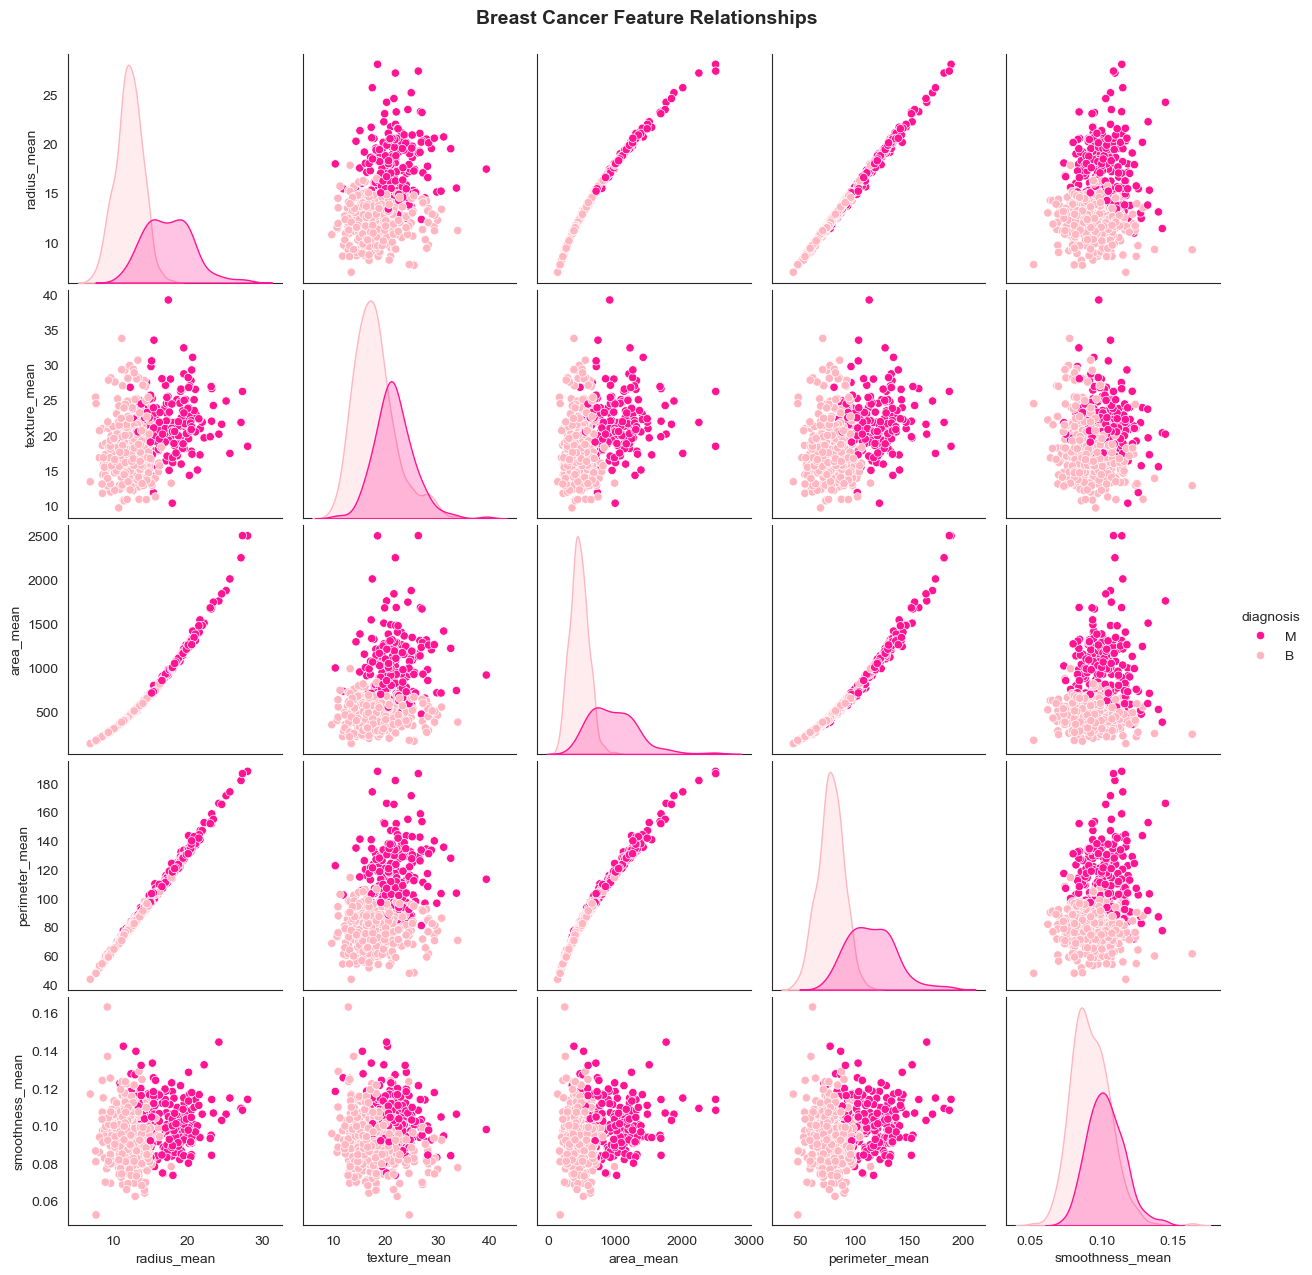

In [144]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set white background
sns.set_style("white")

# Custom pink color palette (Benign = Light Pink, Malignant = Dark Pink)
pink_palette = {
    "B": "#FFB6C1",   # Light Pink
    "M": "#FF1493"    # Deep Pink
}

# Pairplot
sns.pairplot(
    data,
    hue="diagnosis",
    vars=['radius_mean', 'texture_mean',
          'area_mean', 'perimeter_mean',
          'smoothness_mean'],
    palette=pink_palette,
    diag_kind="kde"
)

plt.suptitle("Breast Cancer Feature Relationships ",
             y=1.02,
             fontsize=14,
             fontweight="bold")

plt.show()


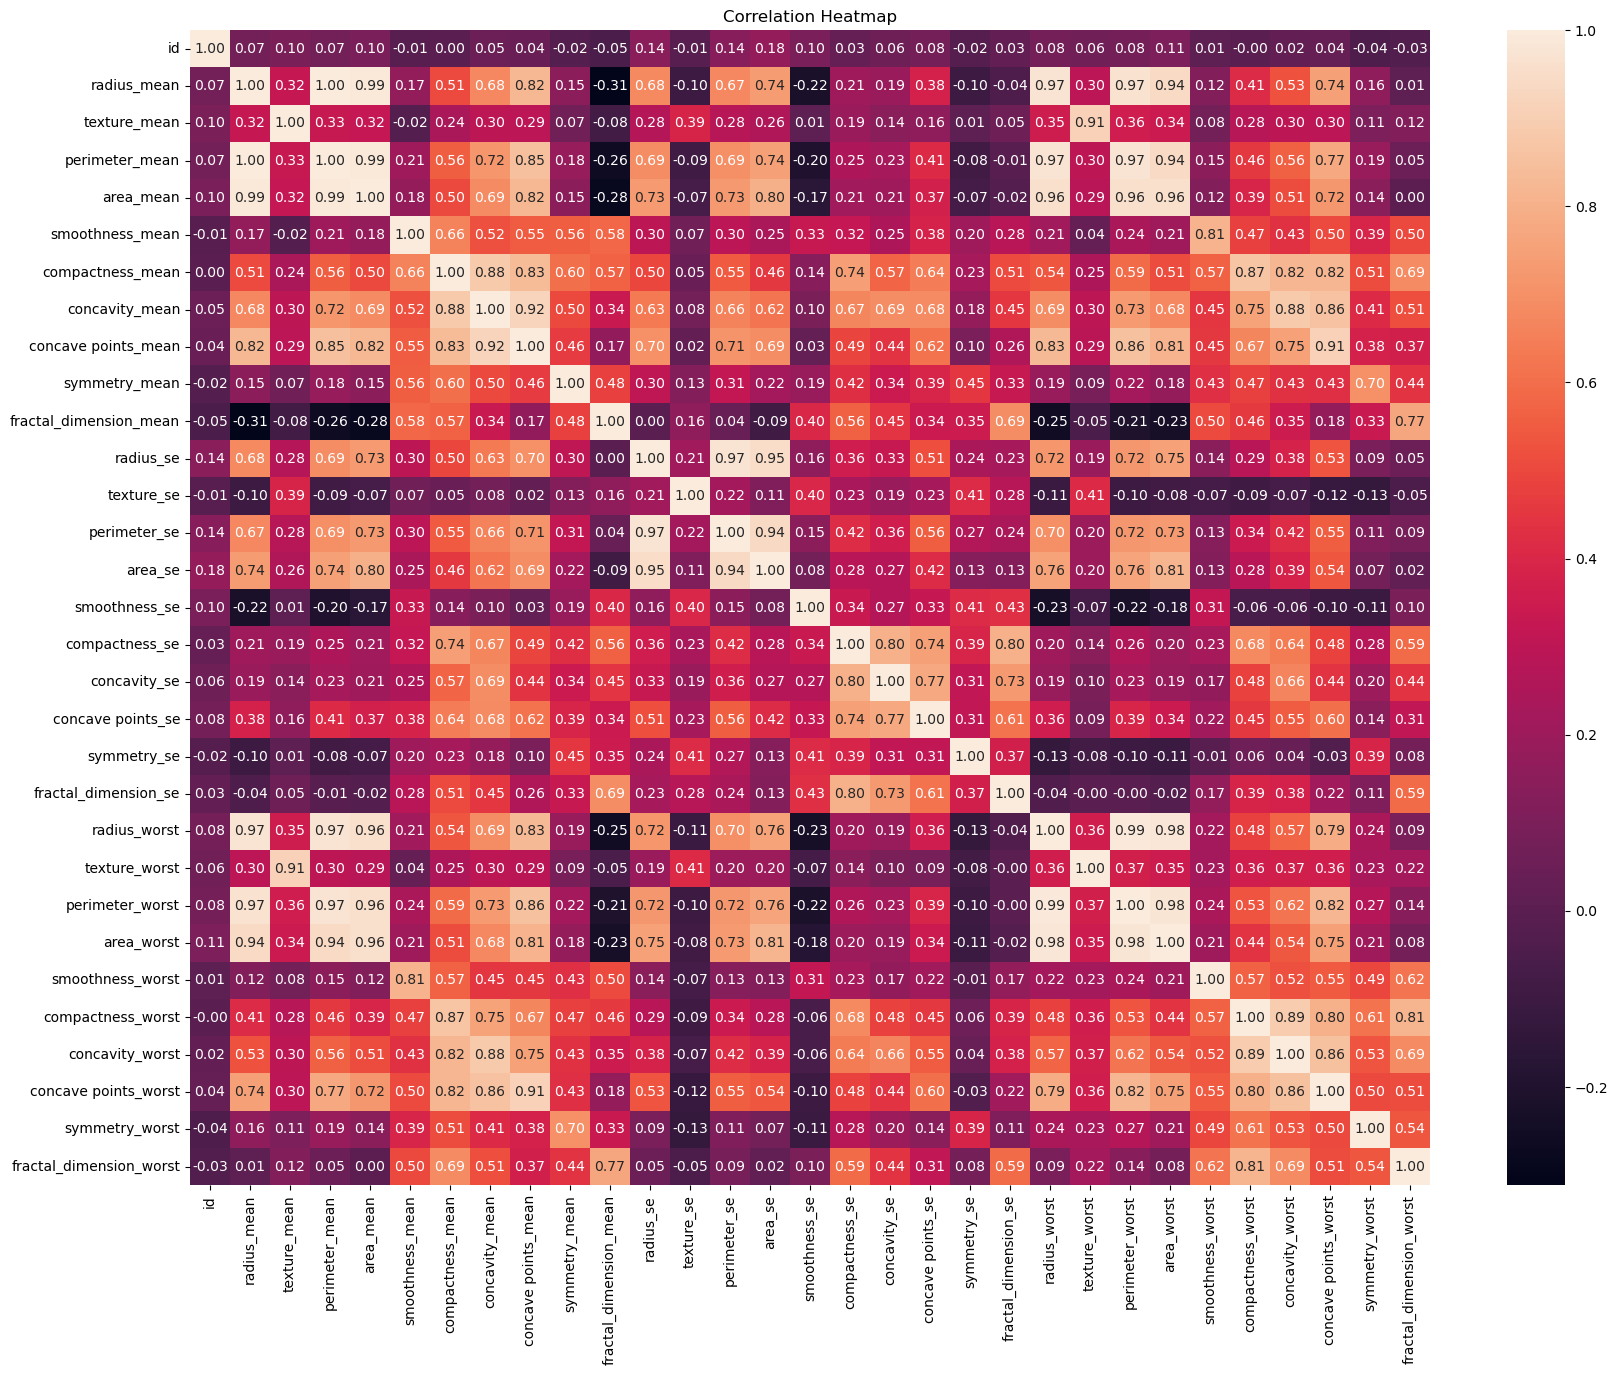

In [18]:
# Correlation heatmap of features
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20,15))
correlation = data.select_dtypes(include=['number']).corr()
sns.heatmap(correlation, annot=True, fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


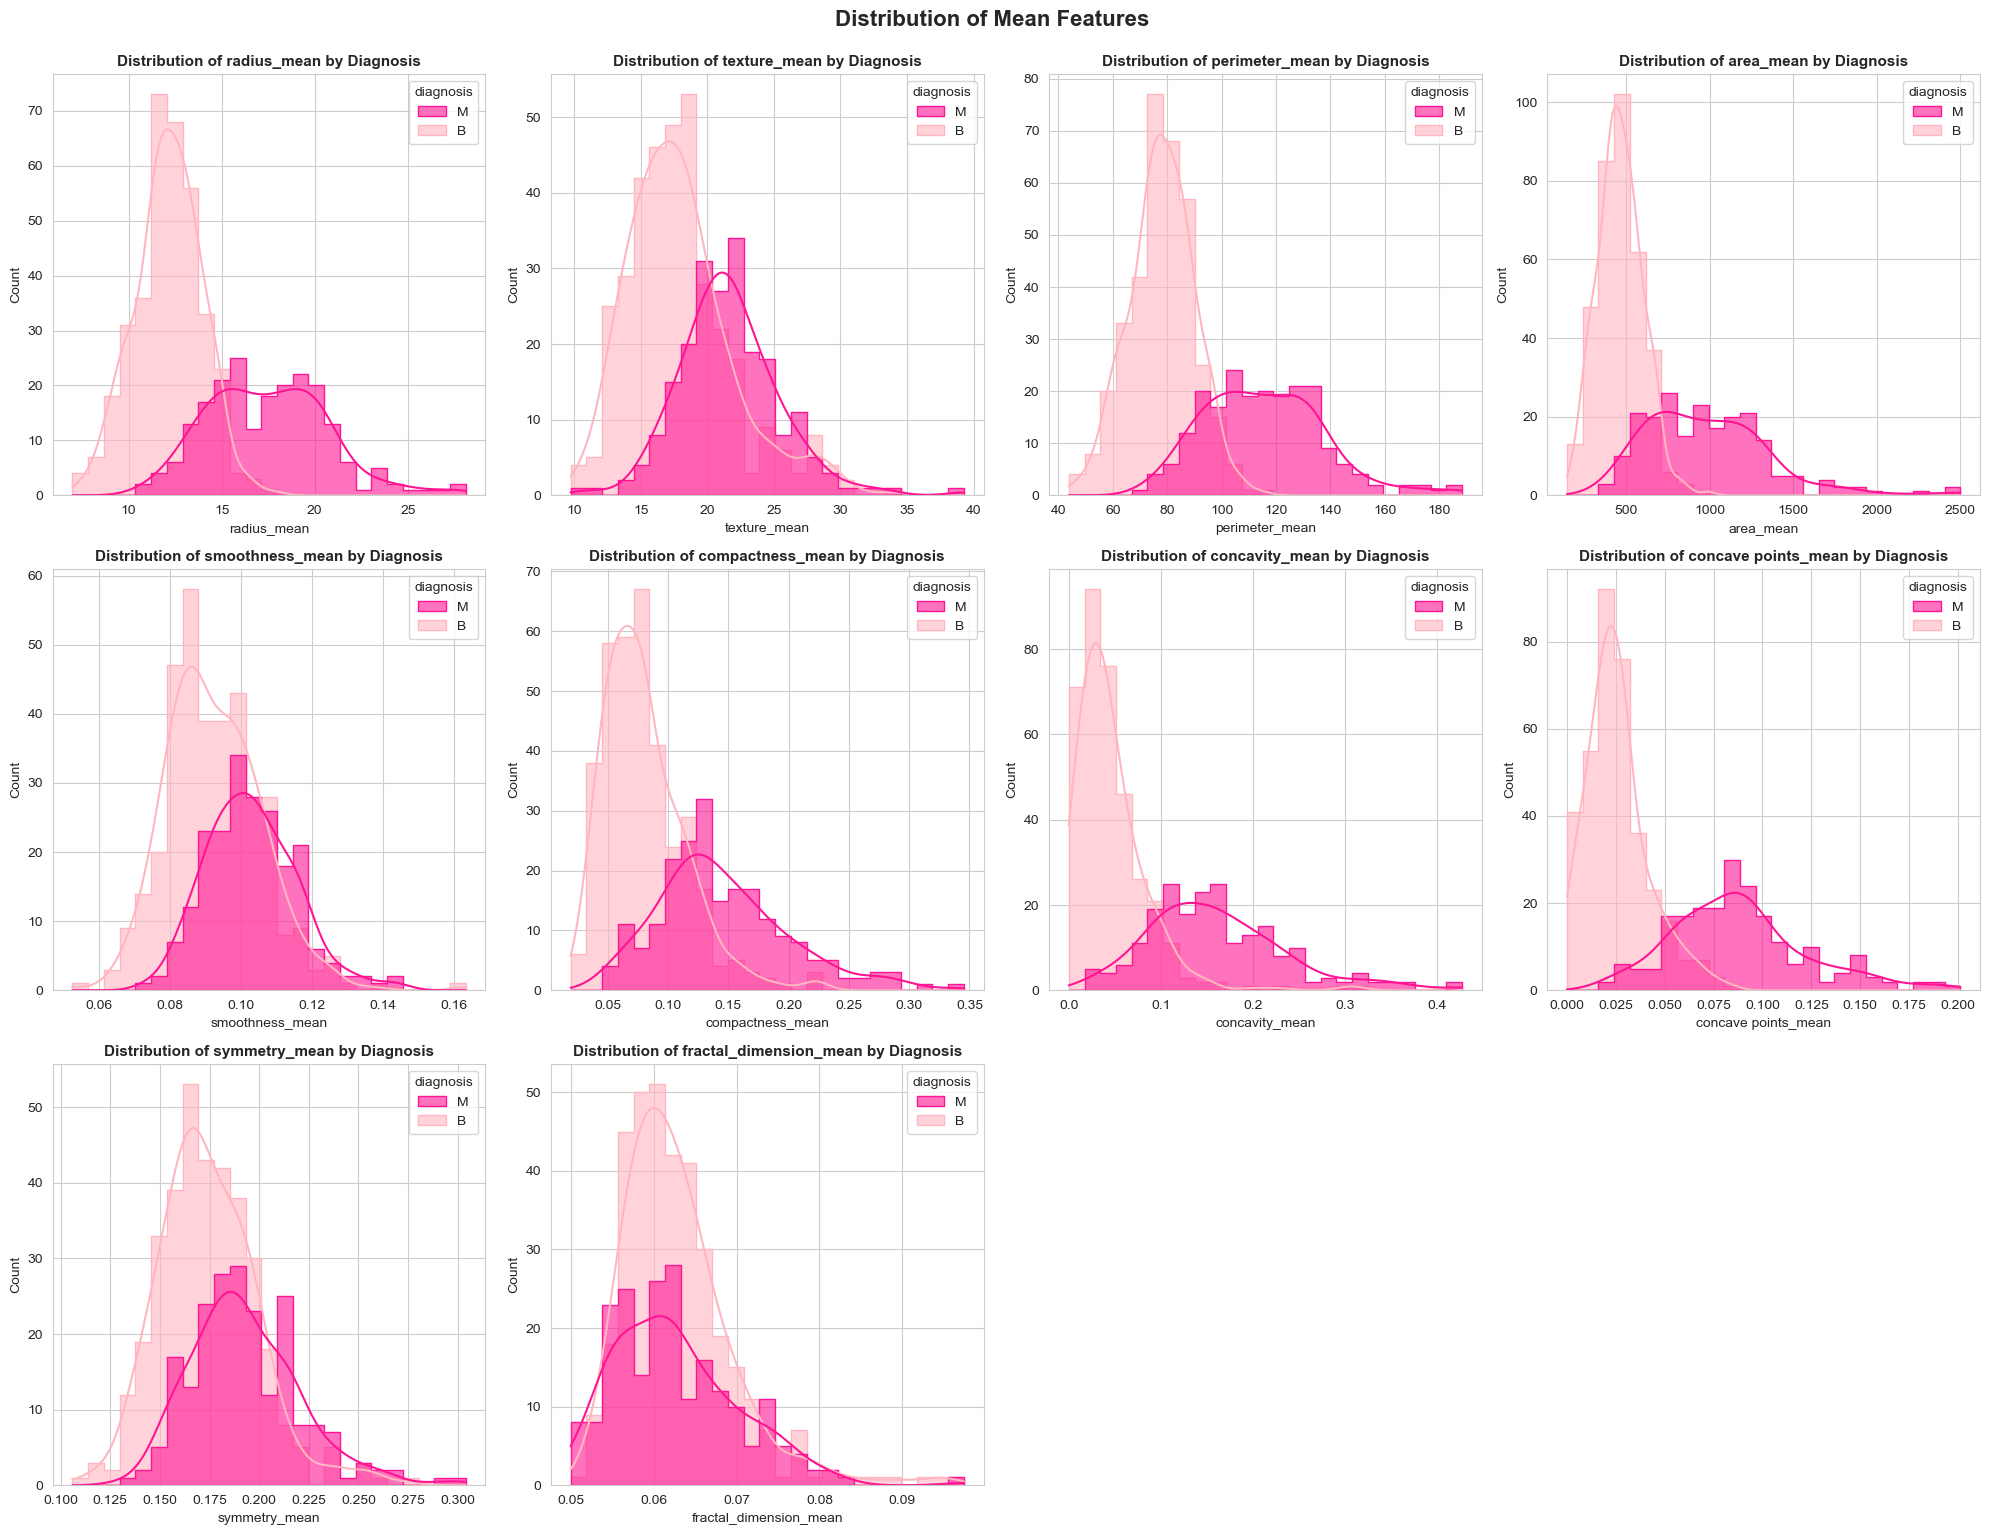

In [145]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select mean feature columns
mean_columns = data.columns[2:12]

# Set white grid style
sns.set_style("whitegrid")

# Pink palette (adjust depending on encoding)
pink_palette = {
    "B": "#FFB6C1",   # Light Pink
    "M": "#FF1493"    # Deep Pink
}

plt.figure(figsize=(20,15))

for i, column in enumerate(mean_columns, 1):
    plt.subplot(3, 4, i)

    sns.histplot(data=data,
                 x=column,
                 hue='diagnosis',
                 kde=True,
                 element="step",
                 bins=25,
                 palette=pink_palette,
                 alpha=0.6)

    plt.title(f'Distribution of {column} by Diagnosis',
              fontsize=11,
              fontweight="bold")

plt.tight_layout()
plt.suptitle("Distribution of Mean Features ",
             fontsize=16,
             fontweight="bold",
             y=1.02)

plt.show()



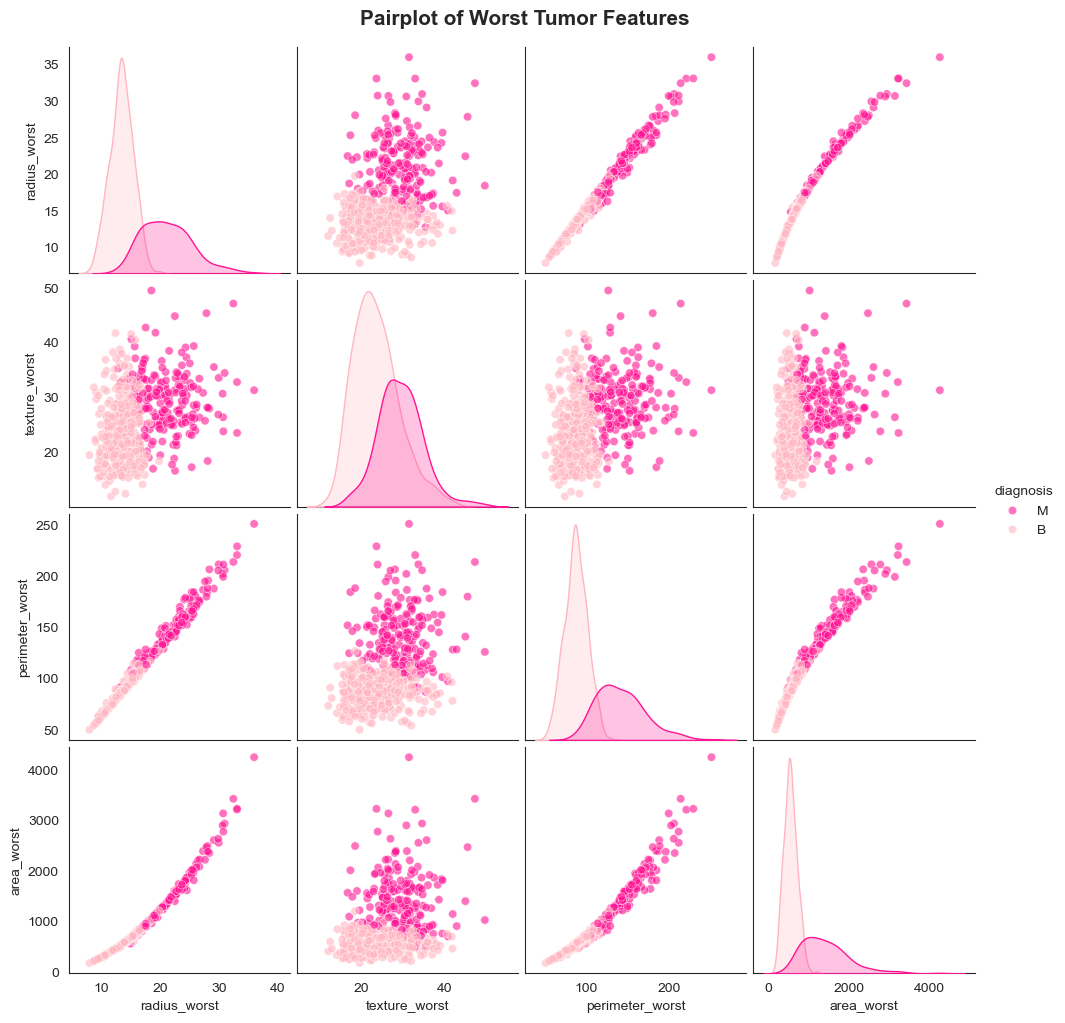

In [146]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select worst features
worst_features = data[['radius_worst',
                       'texture_worst',
                       'perimeter_worst',
                       'area_worst',
                       'diagnosis']]

# Set style
sns.set_style("white")

# Pink palette (if diagnosis = 'M' and 'B')
pink_palette = {
    "B": "#FFB6C1",   # Light Pink
    "M": "#FF1493"    # Deep Pink
}

# Create pairplot
g = sns.pairplot(
    worst_features,
    hue='diagnosis',
    diag_kind='kde',
    palette=pink_palette,
    plot_kws={"alpha": 0.6}
)

# Add title
g.fig.suptitle("Pairplot of Worst Tumor Features ",
               fontsize=15,
               fontweight="bold",
               y=1.02)

plt.show()


# Splitting the dataset

In [21]:
X=data.drop(['id','diagnosis'],axis=1)
y=data['diagnosis'].map(lambda x: 1 if x == 'M' else 0)            

In [22]:
X

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [23]:
y

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: diagnosis, Length: 569, dtype: int64

# Train Test Split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

In [25]:
X_train

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
539,7.691,25.44,48.34,170.4,0.08668,0.11990,0.09252,0.01364,0.2037,0.07751,...,8.678,31.89,54.49,223.6,0.1596,0.30640,0.33930,0.05000,0.2790,0.10660
263,15.610,19.38,100.00,758.6,0.07840,0.05616,0.04209,0.02847,0.1547,0.05443,...,17.910,31.67,115.90,988.6,0.1084,0.18070,0.22600,0.08568,0.2683,0.06829
529,12.070,13.44,77.83,445.2,0.11000,0.09009,0.03781,0.02798,0.1657,0.06608,...,13.450,15.77,86.92,549.9,0.1521,0.16320,0.16220,0.07393,0.2781,0.08052
65,14.780,23.94,97.40,668.3,0.11720,0.14790,0.12670,0.09029,0.1953,0.06654,...,17.310,33.39,114.60,925.1,0.1648,0.34160,0.30240,0.16140,0.3321,0.08911
471,12.040,28.14,76.85,449.9,0.08752,0.06000,0.02367,0.02377,0.1854,0.05698,...,13.600,33.33,87.24,567.6,0.1041,0.09726,0.05524,0.05547,0.2404,0.06639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
344,11.710,15.45,75.03,420.3,0.11500,0.07281,0.04006,0.03250,0.2009,0.06506,...,13.060,18.16,84.16,516.4,0.1460,0.11150,0.10870,0.07864,0.2765,0.07806
277,18.810,19.98,120.90,1102.0,0.08923,0.05884,0.08020,0.05843,0.1550,0.04996,...,19.960,24.30,129.00,1236.0,0.1243,0.11600,0.22100,0.12940,0.2567,0.05737
35,16.740,21.59,110.10,869.5,0.09610,0.13360,0.13480,0.06018,0.1896,0.05656,...,20.010,29.02,133.50,1229.0,0.1563,0.38350,0.54090,0.18130,0.4863,0.08633
171,13.430,19.63,85.84,565.4,0.09048,0.06288,0.05858,0.03438,0.1598,0.05671,...,17.980,29.87,116.60,993.6,0.1401,0.15460,0.26440,0.11600,0.2884,0.07371


In [26]:
X_test

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
452,12.000,28.23,76.77,442.5,0.08437,0.06450,0.040550,0.019450,0.1615,0.06104,...,13.090,37.88,85.07,523.7,0.1208,0.18560,0.181100,0.07116,0.2447,0.08194
456,11.630,29.29,74.87,415.1,0.09357,0.08574,0.071600,0.020170,0.1799,0.06166,...,13.120,38.81,86.04,527.8,0.1406,0.20310,0.292300,0.06835,0.2884,0.07220
393,21.610,22.28,144.40,1407.0,0.11670,0.20870,0.281000,0.156200,0.2162,0.06606,...,26.230,28.74,172.00,2081.0,0.1502,0.57170,0.705300,0.24220,0.3828,0.10070
61,8.598,20.98,54.66,221.8,0.12430,0.08963,0.030000,0.009259,0.1828,0.06757,...,9.565,27.04,62.06,273.9,0.1639,0.16980,0.090010,0.02778,0.2972,0.07712
432,20.180,19.54,133.80,1250.0,0.11330,0.14890,0.213300,0.125900,0.1724,0.06053,...,22.030,25.07,146.00,1479.0,0.1665,0.29420,0.530800,0.21730,0.3032,0.08075
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
562,15.220,30.62,103.40,716.9,0.10480,0.20870,0.255000,0.094290,0.2128,0.07152,...,17.520,42.79,128.70,915.0,0.1417,0.79170,1.170000,0.23560,0.4089,0.14090
428,11.130,16.62,70.47,381.1,0.08151,0.03834,0.013690,0.013700,0.1511,0.06148,...,11.680,20.29,74.35,421.1,0.1030,0.06219,0.045800,0.04044,0.2383,0.07083
107,12.360,18.54,79.01,466.7,0.08477,0.06815,0.026430,0.019210,0.1602,0.06066,...,13.290,27.49,85.56,544.1,0.1184,0.19630,0.193700,0.08442,0.2983,0.07185
333,11.250,14.78,71.38,390.0,0.08306,0.04458,0.000974,0.002941,0.1773,0.06081,...,12.760,22.06,82.08,492.7,0.1166,0.09794,0.005518,0.01667,0.2815,0.07418


In [27]:
y_train

539    0
263    1
529    0
65     1
471    0
      ..
344    0
277    1
35     1
171    1
127    1
Name: diagnosis, Length: 455, dtype: int64

# Scaling the data

In [28]:
scaler = StandardScaler()

In [29]:
X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [30]:
X_train

array([[-1.81223318,  1.46287164, -1.7777162 , ..., -0.98029798,
        -0.18564569,  1.19802142],
       [ 0.40397898,  0.02785411,  0.31347651, ..., -0.43785173,
        -0.3537037 , -0.84313759],
       [-0.58672579, -1.37874723, -0.58396334, ..., -0.61648804,
        -0.19978141, -0.19152249],
       ...,
       [ 0.7202209 ,  0.55118559,  0.72232371, ...,  1.01586773,
         3.07028208,  0.11803465],
       [-0.20611604,  0.0870545 , -0.25971917, ...,  0.02310596,
        -0.03800593, -0.55435968],
       [ 1.35270474, -0.08344263,  1.26070665, ...,  0.11128388,
        -0.10554327, -0.99658415]])

In [31]:
X_train.shape

(455, 30)

In [32]:
y_train.shape

(455,)

In [33]:
y_test.shape

(114,)

In [34]:
X_test.shape

(114, 30)

# Model


In [35]:
compare=pd.DataFrame({'Model':[], "Training Accuracy":[], "Testing Accuracy":[], "F1 Score":[], "Recall":[], 
                     "Precision":[]})
compare

,Model,Training Accuracy,Testing Accuracy,F1 Score,Recall,Precision


* ## Logistic Regression 

In [36]:
LR=LogisticRegression()

In [37]:
LR.fit(X_train,y_train)

LogisticRegression()

In [38]:
y_pred=LR.predict(X_test)
y_pred

array([0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0], dtype=int64)

In [39]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        76
           1       1.00      0.95      0.97        38

    accuracy                           0.98       114
   macro avg       0.99      0.97      0.98       114
weighted avg       0.98      0.98      0.98       114



In [40]:
train_acc=LR.score(X_train,y_train)
test_acc=accuracy_score(y_test,y_pred)
recal=recall_score(y_test,y_pred)
prec=precision_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
print("Training Accuracy :", train_acc)
print("Testing Accuracy :", test_acc)
print("F1 Score :", f1)
print("Recall :", recal)
print("Precision :", prec)

Training Accuracy : 0.989010989010989
Testing Accuracy : 0.9824561403508771
F1 Score : 0.972972972972973
Recall : 0.9473684210526315
Precision : 1.0


In [41]:
compare.loc[0]=['Logistic Regression', train_acc, test_acc, f1, recal, prec]

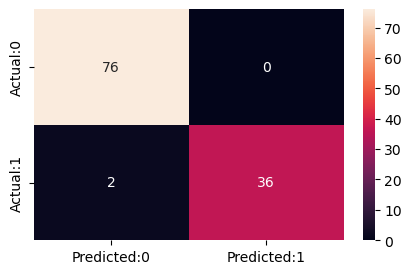

In [42]:
conf_matrix = pd.DataFrame(data = confusion_matrix(y_test,y_pred),
                           columns = ['Predicted:0', 'Predicted:1'],
                           index =['Actual:0', 'Actual:1'])
plt.figure(figsize = (5, 3))
sns.heatmap(conf_matrix, annot = True, fmt = 'd')
plt.show()

* ## Support Vector Machine

In [43]:
svm=SVC()

In [44]:
svm.fit(X_train,y_train)

SVC()

In [45]:
y_pred=svm.predict(X_test)
y_pred

array([0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0], dtype=int64)

In [46]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98        76
           1       0.95      0.97      0.96        38

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [47]:
train_acc=svm.score(X_train,y_train)
test_acc=accuracy_score(y_test,y_pred)
recal=recall_score(y_test,y_pred)
prec=precision_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
print("Training Accuracy :", train_acc)
print("Testing Accuracy :", test_acc)
print("F1 Score :", f1)
print("Recall :", recal)
print("Precision :", prec)

Training Accuracy : 0.989010989010989
Testing Accuracy : 0.9736842105263158
F1 Score : 0.961038961038961
Recall : 0.9736842105263158
Precision : 0.9487179487179487


In [48]:
compare.loc[1]=['Support Vector Machine', train_acc, test_acc, f1, recal, prec]

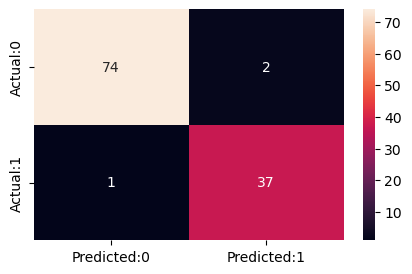

In [49]:
conf_matrix = pd.DataFrame(data = confusion_matrix(y_test,y_pred),
                           columns = ['Predicted:0', 'Predicted:1'],
                           index =['Actual:0', 'Actual:1'])
plt.figure(figsize = (5, 3))
sns.heatmap(conf_matrix, annot = True, fmt = 'd')
plt.show()

* ## KNN

In [50]:
knn=KNeighborsClassifier(n_neighbors=9)

In [51]:
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=9)

In [52]:
y_pred=knn.predict(X_test)
y_pred

array([0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0], dtype=int64)

In [53]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96        76
           1       0.94      0.89      0.92        38

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



In [54]:
train_acc=knn.score(X_train,y_train)
test_acc=accuracy_score(y_test,y_pred)
recal=recall_score(y_test,y_pred)
prec=precision_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
print("Training Accuracy :", train_acc)
print("Testing Accuracy :", test_acc)
print("F1 Score :", f1)
print("Recall :", recal)
print("Precision :", prec)

Training Accuracy : 0.9802197802197802
Testing Accuracy : 0.9473684210526315
F1 Score : 0.918918918918919
Recall : 0.8947368421052632
Precision : 0.9444444444444444


In [55]:
compare.loc[2]=['KNN', train_acc, test_acc, f1, recal, prec]

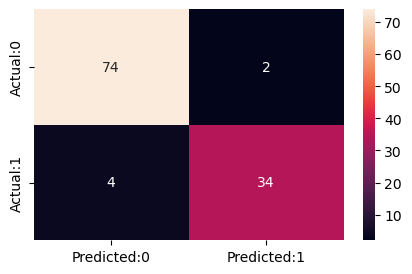

In [56]:
conf_matrix = pd.DataFrame(data = confusion_matrix(y_test,y_pred),
                           columns = ['Predicted:0', 'Predicted:1'],
                           index =['Actual:0', 'Actual:1'])
plt.figure(figsize = (5, 3))
sns.heatmap(conf_matrix, annot = True, fmt = 'd')
plt.show()

* ## Naives Bayes

In [57]:
NB = GaussianNB()

In [58]:
NB.fit(X_train,y_train)

GaussianNB()

In [59]:
y_pred=NB.predict(X_test)
y_pred

array([0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0], dtype=int64)

In [60]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.93      0.93        76
           1       0.86      0.84      0.85        38

    accuracy                           0.90       114
   macro avg       0.89      0.89      0.89       114
weighted avg       0.90      0.90      0.90       114



In [61]:
train_acc=NB.score(X_train,y_train)
test_acc=accuracy_score(y_test,y_pred)
recal=recall_score(y_test,y_pred)
prec=precision_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
print("Training Accuracy :", train_acc)
print("Testing Accuracy :", test_acc)
print("F1 Score :", f1)
print("Recall :", recal)
print("Precision :", prec)

Training Accuracy : 0.9494505494505494
Testing Accuracy : 0.9035087719298246
F1 Score : 0.8533333333333334
Recall : 0.8421052631578947
Precision : 0.8648648648648649


In [62]:
compare.loc[3]=['Gaussian Naives Bayes', train_acc, test_acc, f1, recal, prec]

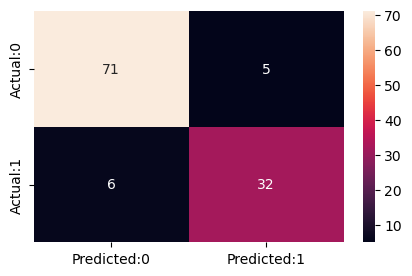

In [63]:
conf_matrix = pd.DataFrame(data = confusion_matrix(y_test,y_pred),
                           columns = ['Predicted:0', 'Predicted:1'],
                           index =['Actual:0', 'Actual:1'])
plt.figure(figsize = (5, 3))
sns.heatmap(conf_matrix, annot = True, fmt = 'd')
plt.show()

* ## Decision Tree

In [64]:
DT=DecisionTreeClassifier(random_state=8)

In [65]:
DT.fit(X_train,y_train)

DecisionTreeClassifier(random_state=8)

In [66]:
y_pred=DT.predict(X_test)
y_pred

array([0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0], dtype=int64)

In [67]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      0.89      0.93        76
           1       0.81      0.92      0.86        38

    accuracy                           0.90       114
   macro avg       0.89      0.91      0.89       114
weighted avg       0.91      0.90      0.90       114



In [68]:
train_acc=DT.score(X_train,y_train)
test_acc=accuracy_score(y_test,y_pred)
recal=recall_score(y_test,y_pred)
prec=precision_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
print("Training Accuracy :", train_acc)
print("Testing Accuracy :", test_acc)
print("F1 Score :", f1)
print("Recall :", recal)
print("Precision :", prec)

Training Accuracy : 1.0
Testing Accuracy : 0.9035087719298246
F1 Score : 0.8641975308641975
Recall : 0.9210526315789473
Precision : 0.813953488372093


In [69]:
compare.loc[4]=['Decision Tree', train_acc, test_acc, f1, recal, prec]

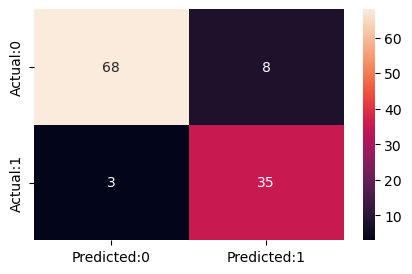

In [70]:
conf_matrix = pd.DataFrame(data = confusion_matrix(y_test,y_pred),
                           columns = ['Predicted:0', 'Predicted:1'],
                           index =['Actual:0', 'Actual:1'])
plt.figure(figsize = (5, 3))
sns.heatmap(conf_matrix, annot = True, fmt = 'd')
plt.show()

* ## Random forest

In [71]:
RF=RandomForestClassifier(n_estimators=50,random_state=1)

In [72]:
RF.fit(X_train,y_train)

RandomForestClassifier(n_estimators=50, random_state=1)

In [73]:
y_pred=RF.predict(X_test)
y_pred

array([0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0], dtype=int64)

In [74]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      0.95      0.95        76
           1       0.90      0.92      0.91        38

    accuracy                           0.94       114
   macro avg       0.93      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



In [75]:
train_acc=RF.score(X_train,y_train)
test_acc=accuracy_score(y_test,y_pred)
recal=recall_score(y_test,y_pred)
prec=precision_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
print("Training Accuracy :", train_acc)
print("Testing Accuracy :", test_acc)
print("F1 Score :", f1)
print("Recall :", recal)
print("Precision :", prec)

Training Accuracy : 1.0
Testing Accuracy : 0.9385964912280702
F1 Score : 0.9090909090909091
Recall : 0.9210526315789473
Precision : 0.8974358974358975


In [76]:
compare.loc[5]=['Random forest', train_acc, test_acc, f1, recal, prec]

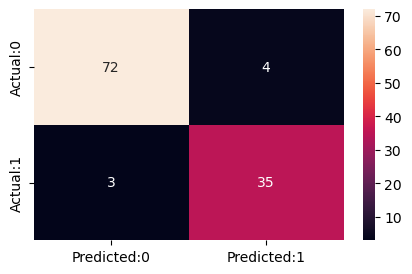

In [77]:
conf_matrix = pd.DataFrame(data = confusion_matrix(y_test,y_pred),
                           columns = ['Predicted:0', 'Predicted:1'],
                           index =['Actual:0', 'Actual:1'])
plt.figure(figsize = (5, 3))
sns.heatmap(conf_matrix, annot = True, fmt = 'd')
plt.show()

* ## Gradient Boosting

In [78]:
GB=GradientBoostingClassifier(n_estimators=12)

In [79]:
GB.fit(X_train,y_train)

GradientBoostingClassifier(n_estimators=12)

In [80]:
y_pred=GB.predict(X_test)
y_pred

array([0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0], dtype=int64)

In [81]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.92      0.93        76
           1       0.85      0.89      0.87        38

    accuracy                           0.91       114
   macro avg       0.90      0.91      0.90       114
weighted avg       0.91      0.91      0.91       114



In [82]:
train_acc=GB.score(X_train,y_train)
test_acc=accuracy_score(y_test,y_pred)
recal=recall_score(y_test,y_pred)
prec=precision_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
print("Training Accuracy :", train_acc)
print("Testing Accuracy :", test_acc)
print("F1 Score :", f1)
print("Recall :", recal)
print("Precision :", prec)

Training Accuracy : 0.989010989010989
Testing Accuracy : 0.9122807017543859
F1 Score : 0.8717948717948718
Recall : 0.8947368421052632
Precision : 0.85


In [83]:
compare.loc[6]=['Gradient Boosting', train_acc, test_acc, f1, recal, prec]

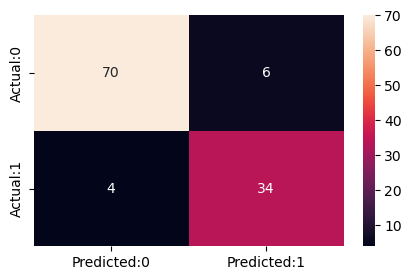

In [84]:
conf_matrix = pd.DataFrame(data = confusion_matrix(y_test,y_pred),
                           columns = ['Predicted:0', 'Predicted:1'],
                           index =['Actual:0', 'Actual:1'])
plt.figure(figsize = (5, 3))
sns.heatmap(conf_matrix, annot = True, fmt = 'd')
plt.show()

* ## Stochastic Gradient Descent

In [85]:
SGD=SGDClassifier(loss='modified_huber', random_state=10)

In [86]:
SGD.fit(X_train,y_train)

SGDClassifier(loss='modified_huber', random_state=10)

In [87]:
y_pred=SGD.predict(X_test)
y_pred

array([0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0], dtype=int64)

In [88]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.96      0.97        76
           1       0.92      0.95      0.94        38

    accuracy                           0.96       114
   macro avg       0.95      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [89]:
train_acc=SGD.score(X_train,y_train)
test_acc=accuracy_score(y_test,y_pred)
recal=recall_score(y_test,y_pred)
prec=precision_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
print("Training Accuracy :", train_acc)
print("Testing Accuracy :", test_acc)
print("F1 Score :", f1)
print("Recall :", recal)
print("Precision :", prec)

Training Accuracy : 0.9846153846153847
Testing Accuracy : 0.956140350877193
F1 Score : 0.935064935064935
Recall : 0.9473684210526315
Precision : 0.9230769230769231


In [90]:
compare.loc[7]=['Stochastic Gradient Descent', train_acc, test_acc, f1, recal, prec]

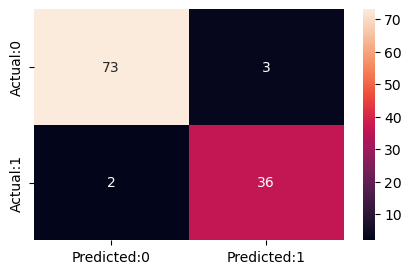

In [91]:
conf_matrix = pd.DataFrame(data = confusion_matrix(y_test,y_pred),
                           columns = ['Predicted:0', 'Predicted:1'],
                           index =['Actual:0', 'Actual:1'])
plt.figure(figsize = (5, 3))
sns.heatmap(conf_matrix, annot = True, fmt = 'd')
plt.show()

* ## XGBoost	

In [92]:
XGB= XGBClassifier(random_state=0,n_estimators=88,booster='gbtree') 

In [93]:
XGB.fit(X_train,y_train)

XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=88,
              n_jobs=None, num_parallel_tree=None, ...)

In [94]:
y_pred=XGB.predict(X_test)
y_pred

array([0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0])

In [95]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      0.93      0.95        76
           1       0.88      0.92      0.90        38

    accuracy                           0.93       114
   macro avg       0.92      0.93      0.92       114
weighted avg       0.93      0.93      0.93       114



In [96]:
train_acc=XGB.score(X_train,y_train)
test_acc=accuracy_score(y_test,y_pred)
recal=recall_score(y_test,y_pred)
prec=precision_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
print("Training Accuracy :", train_acc)
print("Testing Accuracy :", test_acc)
print("F1 Score :", f1)
print("Recall :", recal)
print("Precision :", prec)

Training Accuracy : 1.0
Testing Accuracy : 0.9298245614035088
F1 Score : 0.8974358974358975
Recall : 0.9210526315789473
Precision : 0.875


In [97]:
compare.loc[8]=['XGBoost', train_acc, test_acc, f1, recal, prec]

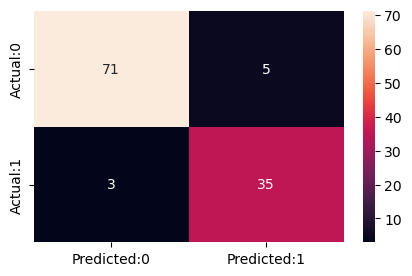

In [98]:
conf_matrix = pd.DataFrame(data = confusion_matrix(y_test,y_pred),
                           columns = ['Predicted:0', 'Predicted:1'],
                           index =['Actual:0', 'Actual:1'])
plt.figure(figsize = (5, 3))
sns.heatmap(conf_matrix, annot = True, fmt = 'd')
plt.show()

* ## LGBM

In [99]:
LGBM=LGBMClassifier(random_state=0,n_estimators=22)

In [100]:
LGBM.fit(X_train,y_train)

[LightGBM] [Info] Number of positive: 174, number of negative: 281
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000556 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4545
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.382418 -> initscore=-0.479299
[LightGBM] [Info] Start training from score -0.479299
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

LGBMClassifier(n_estimators=22, random_state=0)

In [101]:
y_pred=LGBM.predict(X_test)
y_pred

array([0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0], dtype=int64)

In [102]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.96      0.95        76
           1       0.92      0.89      0.91        38

    accuracy                           0.94       114
   macro avg       0.93      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



In [103]:
train_acc=LGBM.score(X_train,y_train)
test_acc=accuracy_score(y_test,y_pred)
recal=recall_score(y_test,y_pred)
prec=precision_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
print("Training Accuracy :", train_acc)
print("Testing Accuracy :", test_acc)
print("F1 Score :", f1)
print("Recall :", recal)
print("Precision :", prec)

Training Accuracy : 0.9868131868131869
Testing Accuracy : 0.9385964912280702
F1 Score : 0.9066666666666666
Recall : 0.8947368421052632
Precision : 0.918918918918919


In [104]:
compare.loc[9]=['LGBM', train_acc, test_acc, f1, recal, prec]

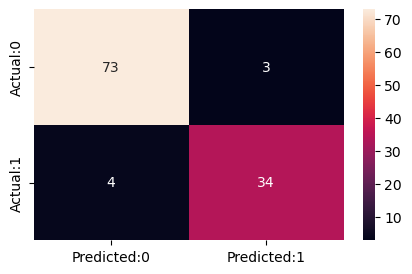

In [105]:
conf_matrix = pd.DataFrame(data = confusion_matrix(y_test,y_pred),
                           columns = ['Predicted:0', 'Predicted:1'],
                           index =['Actual:0', 'Actual:1'])
plt.figure(figsize = (5, 3))
sns.heatmap(conf_matrix, annot = True, fmt = 'd')
plt.show()

* ## Neural Network

In [106]:
model=keras.Sequential([
    keras.layers.Flatten(input_shape=(30,)),
    keras.layers.Dense(100,activation='relu'),
    keras.layers.Dense(2,activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [107]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 30)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 100)                 │           3,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             202 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,302 (12.90 KB)

 Trainable params: 3,302 (12.90 KB)

 Non-trainable params: 0 (0.00 B)

In [108]:
history=model.fit(X_train,y_train,epochs=20,validation_split=0.1,shuffle=True)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7555 - loss: 0.5122 - val_accuracy: 0.9565 - val_loss: 0.2651
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9193 - loss: 0.2427 - val_accuracy: 0.9565 - val_loss: 0.1493
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9462 - loss: 0.1665 - val_accuracy: 0.9783 - val_loss: 0.1051
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9633 - loss: 0.1321 - val_accuracy: 0.9783 - val_loss: 0.0840
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9780 - loss: 0.1121 - val_accuracy: 0.9783 - val_loss: 0.0720
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9829 - loss: 0.0989 - val_accuracy: 0.9783 - val_loss: 0.0640
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9853 - loss: 0.0893 - val_accuracy: 1.0000 - val_loss: 0.0580
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9853 - loss: 0.0819 - val_accuracy: 1.0000 - val_loss

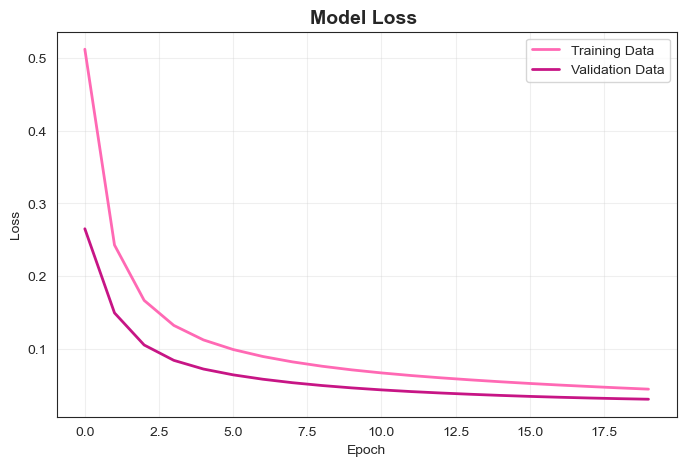

In [149]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Pink shades
train_color = "#FF69B4"   # Hot Pink
val_color = "#C71585"     # Medium Violet Red

plt.plot(history.history['loss'],
         color=train_color,
         linewidth=2)

plt.plot(history.history['val_loss'],
         color=val_color,
         linewidth=2)

plt.title('Model Loss ',
          fontsize=14,
          fontweight='bold')

plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Training Data', 'Validation Data'],
           loc='upper right')

plt.grid(alpha=0.3)
plt.show()


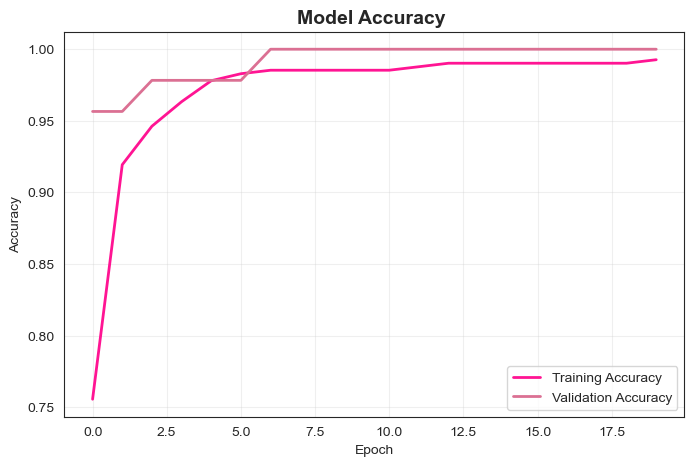

In [150]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],
         color="#FF1493",
         linewidth=2)

plt.plot(history.history['val_accuracy'],
         color="#DB7093",
         linewidth=2)

plt.title('Model Accuracy ',
          fontsize=14,
          fontweight='bold')

plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Training Accuracy', 'Validation Accuracy'],
           loc='lower right')

plt.grid(alpha=0.3)
plt.show()


In [111]:
loss, accuracy = model.evaluate(X_test, y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9649 - loss: 0.1181


In [112]:
X_test[0]

array([-0.60631599,  2.12354803, -0.62687205, -0.60135713, -0.85541098,
       -0.74241948, -0.59677343, -0.75975556, -0.71737141, -0.2494044 ,
       -0.77904901,  0.9110865 , -0.66788074, -0.57755838,  0.1201748 ,
        0.02469421, -0.07562444, -0.42287291, -0.3811877 ,  0.19401522,
       -0.66300531,  2.04058337, -0.66188584, -0.62609835, -0.51971025,
       -0.43013458, -0.42886558, -0.65860059, -0.72437372, -0.1158648 ])

In [113]:
y_pred = model.predict(X_test)
y_pred

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


array([[8.49467516e-01, 9.69121829e-02],
       [7.34706998e-01, 3.76578122e-01],
       [1.03641546e-03, 9.99974966e-01],
       [9.83043492e-01, 2.92501673e-02],
       [1.07061593e-02, 9.98088121e-01],
       [9.08687115e-01, 1.63282845e-02],
       [6.45494521e-01, 4.28130239e-01],
       [6.05771840e-01, 4.82639998e-01],
       [1.26230225e-01, 9.81287003e-01],
       [9.01939988e-01, 1.11847118e-01],
       [9.19647157e-01, 2.55312975e-02],
       [9.40845311e-01, 9.09008179e-03],
       [4.78988737e-02, 9.65303302e-01],
       [5.18979225e-03, 9.99610484e-01],
       [4.51605618e-02, 9.43220675e-01],
       [8.90187144e-01, 2.36879047e-02],
       [5.58021307e-01, 4.44252044e-01],
       [1.34851933e-01, 9.94394839e-01],
       [9.85497534e-01, 2.06701085e-03],
       [8.98010910e-01, 5.43057173e-02],
       [7.08891273e-01, 1.18348181e-01],
       [9.82923627e-01, 9.76061169e-03],
       [8.77223670e-01, 4.84893322e-02],
       [9.71282303e-01, 3.33797708e-02],
       [1.177622

In [114]:
y_pred[0]

array([0.8494675 , 0.09691218], dtype=float32)

In [115]:
np.argmax(y_pred[0])

0

In [116]:
y_test[:1]

452    0
Name: diagnosis, dtype: int64

In [117]:
y_pred_labels = [np.argmax(i) for i in y_pred]
y_pred_labels

[0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0]

In [118]:
print(classification_report(y_test,y_pred_labels))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        76
           1       0.95      0.95      0.95        38

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



In [119]:
accuracy

0.9649122953414917

In [120]:
metric = tf.keras.metrics.Recall()
metric.update_state(y_test, y_pred_labels)
print("Recall =",metric.result().numpy())

Recall = 0.94736844


In [121]:
m = tf.keras.metrics.Precision()
m.update_state(y_test, y_pred_labels)
print("Precision =",m.result().numpy())

Precision = 0.94736844


In [122]:
y_pred_train_labels=[np.argmax(i) for i in model.predict(X_train)] 
y_pred_train_labels

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


[0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,


In [123]:
train_acc=accuracy_score(y_train,y_pred_train_labels)
test_acc=accuracy_score(y_test,y_pred_labels)
recal=recall_score(y_test,y_pred_labels)
prec=precision_score(y_test,y_pred_labels)
f1=f1_score(y_test,y_pred_labels)
print("Training Accuracy :", train_acc)
print("Testing Accuracy :", test_acc)
print("F1 Score :", f1)
print("Recall :", recal)
print("Precision :", prec)

Training Accuracy : 0.9934065934065934
Testing Accuracy : 0.9649122807017544
F1 Score : 0.9473684210526315
Recall : 0.9473684210526315
Precision : 0.9473684210526315


In [124]:
compare.loc[10]=['Neural Network', train_acc, test_acc, f1, recal, prec]

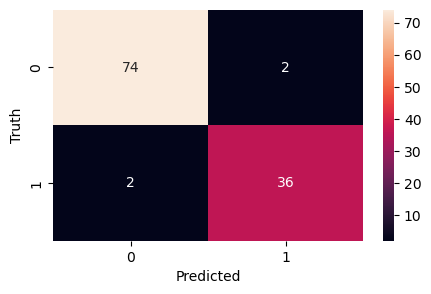

In [125]:
cm = tf.math.confusion_matrix(y_test,y_pred_labels)
plt.figure(figsize = (5,3))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

# Model Selection / Conclusion

In [126]:
compare

,Model,Training Accuracy,Testing Accuracy,F1 Score,Recall,Precision
0,Logistic Regression,0.989011,0.982456,0.972973,0.947368,1.000000
1,Support Vector Machine,0.989011,0.973684,0.961039,0.973684,0.948718
2,KNN,0.980220,0.947368,0.918919,0.894737,0.944444
3,Gaussian Naives Bayes,0.949451,0.903509,0.853333,0.842105,0.864865
4,Decision Tree,1.000000,0.903509,0.864198,0.921053,0.813953
5,Random forest,1.000000,0.938596,0.909091,0.921053,0.897436
6,Gradient Boosting,0.989011,0.912281,0.871795,0.894737,0.850000
7,Stochastic Gradient Descent,0.984615,0.956140,0.935065,0.947368,0.923077
8,XGBoost,1.000000,0.929825,0.897436,0.921053,0.875000
9,LGBM,0.986813,0.938596,0.906667,0.894737,0.918919


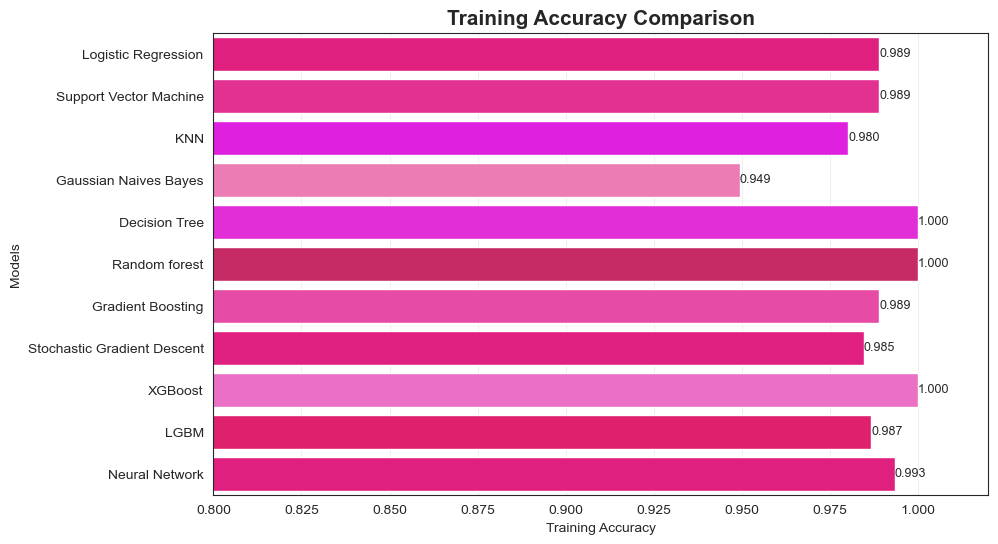

In [153]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Bright neon pink palette
bright_pink_palette = [
    "#FF007F",  # Bright Rose
    "#FF1493",  # Deep Pink
    "#FF00FF",  # Magenta
    "#FF69B4",  # Hot Pink
    "#FF10F0",  # Neon Pink
    "#E0115F",  # Ruby Pink
    "#FF33AA",  # Bright Candy Pink
    "#FF0080",  # Electric Pink
    "#FF5CCD",  # Vibrant Pink
    "#FF0066"   # Strong Pink
]

ax = sns.barplot(data=compare,
                 y='Model',
                 x='Training Accuracy',
                 palette=bright_pink_palette)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9)

plt.title("Training Accuracy Comparison",
          fontsize=15,
          fontweight="bold")

plt.xlim(0.8, 1.02)
plt.xlabel("Training Accuracy")
plt.ylabel("Models")

plt.grid(axis='x', alpha=0.3)
plt.show()


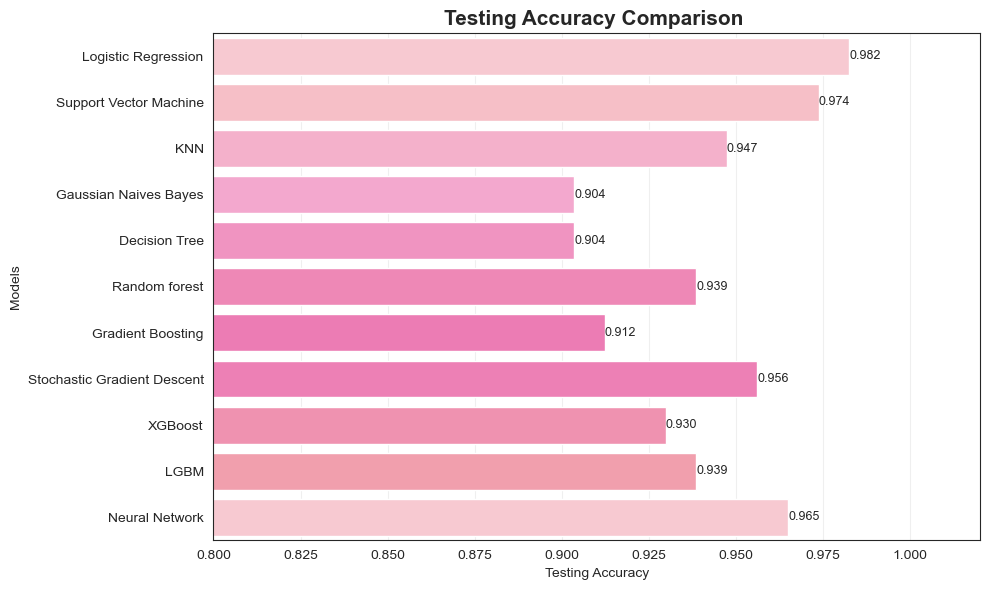

In [155]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Soft but slightly bright pink shades
soft_bright_pink = [
    "#FFC1CC",  # Soft Pink
    "#FFB6C1",  # Light Pink
    "#FFA6C9",  # Baby Pink
    "#FF9BCF",  # Bright Light Pink
    "#FF85C1",  # Soft Hot Pink
    "#FF77B4",  # Bright Soft Pink
    "#FF69B4",  # Hot Pink
    "#FF6EB4",  # Orchid Pink
    "#FF82AB",  # Rosy Pink
    "#FF91A4"   # Soft Rose
]

ax = sns.barplot(data=compare,
                 y='Model',
                 x='Testing Accuracy',
                 palette=soft_bright_pink)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9)

plt.title("Testing Accuracy Comparison ",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Testing Accuracy")
plt.ylabel("Models")

plt.xlim(0.8, 1.02)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


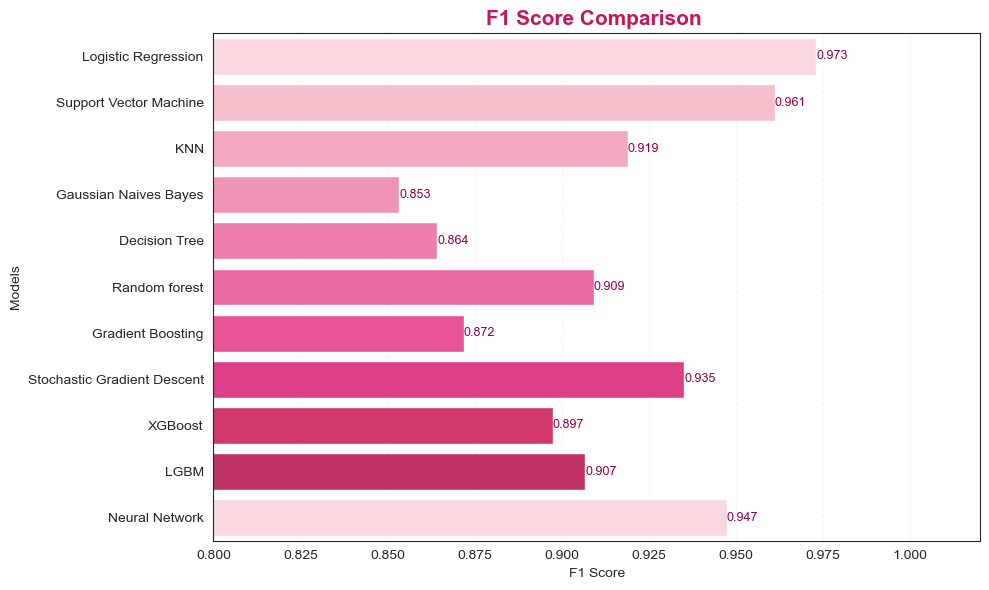

In [159]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Slightly deeper rose-pink palette
rose_pink_palette = [
    "#FFD1DC",
    "#FFB7C5",
    "#FF9EBB",
    "#FF85B3",
    "#FF6CAB",
    "#FF539F",
    "#FF3B95",
    "#F72585",
    "#E91E63",
    "#D81B60"
]

sns.set_style("white")

ax = sns.barplot(data=compare,
                 y='Model',
                 x='F1 Score',
                 palette=rose_pink_palette)

# Value labels with darker pink text
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f',
                 fontsize=9,
                 color="#8B004B")

plt.title("F1 Score Comparison ",
          fontsize=15,
          fontweight="bold",
          color="#C2185B")

plt.xlabel("F1 Score")
plt.ylabel("Models")

plt.xlim(0.8, 1.02)

plt.grid(axis='x', linestyle='--', alpha=0.2)
plt.tight_layout()
plt.show()


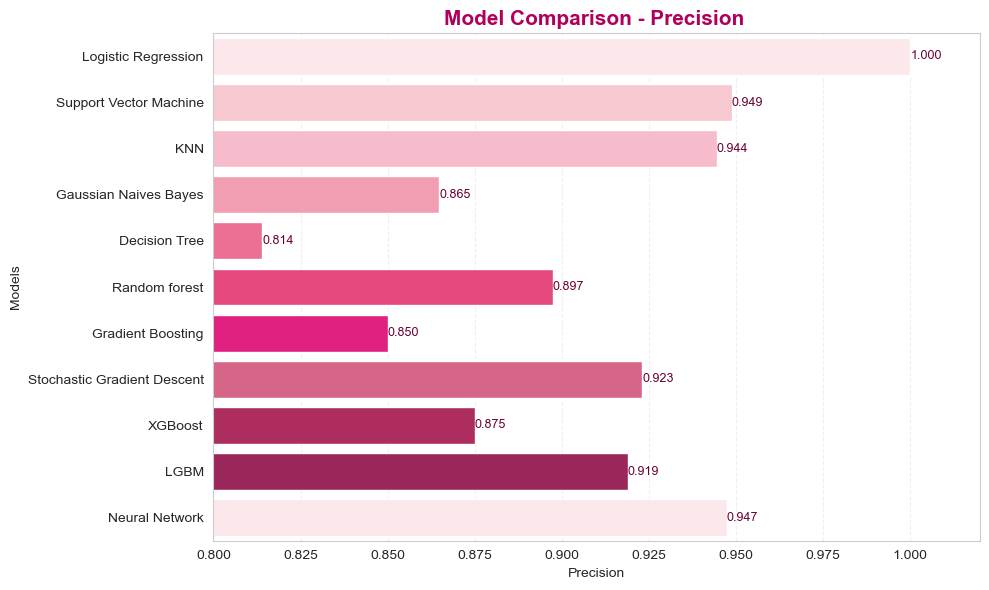

In [160]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Different pink shades (pastel → vibrant)
precision_pink_palette = [
    "#FFE4E9",  # Very Light Pink
    "#FFC0CB",  # Pink
    "#FFB3C6",  # Soft Rose
    "#FF8FAB",  # Medium Pink
    "#FF5C8A",  # Bright Rose
    "#FF2E74",  # Strong Pink
    "#FF007F",  # Bright Rose
    "#E75480",  # Dark Pink
    "#C2185B",  # Deep Rose
    "#AD1457"   # Rich Pink
]

sns.set_style("whitegrid")

ax = sns.barplot(data=compare,
                 y='Model',
                 x='Precision',
                 palette=precision_pink_palette)

# Add value labels
for container in ax.containers:
    ax.bar_label(container,
                 fmt='%.3f',
                 fontsize=9,
                 color="#6A0032")

plt.title("Model Comparison - Precision ",
          fontsize=15,
          fontweight="bold",
          color="#B0005B")

plt.xlabel("Precision")
plt.ylabel("Models")

plt.xlim(0.8, 1.02)

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


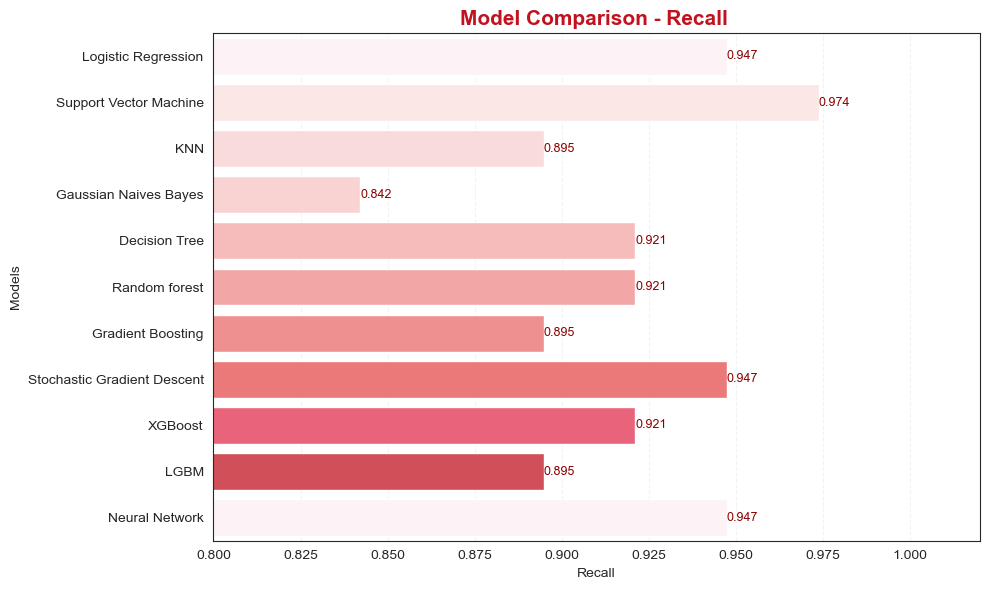

In [161]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Pink shades close to white → red
recall_pink_palette = [
    "#FFF0F5",  # Lavender Blush (near white)
    "#FFE4E1",  # Misty Rose
    "#FFD6D6",  # Very Light Pink
    "#FFCCCC",  # Soft Pink
    "#FFB3B3",  # Light Rosy
    "#FF9999",  # Rosy Pink
    "#FF8080",  # Soft Red-Pink
    "#FF6666",  # Light Red
    "#FF4D6D",  # Rose Red
    "#E63946"   # Deep Red-Pink
]

sns.set_style("white")

ax = sns.barplot(data=compare,
                 y='Model',
                 x='Recall',
                 palette=recall_pink_palette)

# Add value labels
for container in ax.containers:
    ax.bar_label(container,
                 fmt='%.3f',
                 fontsize=9,
                 color="#8B0000")

plt.title("Model Comparison - Recall ",
          fontsize=15,
          fontweight="bold",
          color="#C1121F")

plt.xlabel("Recall")
plt.ylabel("Models")

plt.xlim(0.8, 1.02)

plt.grid(axis='x', linestyle='--', alpha=0.25)
plt.tight_layout()
plt.show()


In [134]:
from sklearn.neural_network import MLPClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Support Vector Machine": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Gaussian Naives Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Stochastic Gradient Descent": SGDClassifier(loss='log_loss'),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "LGBM": LGBMClassifier(),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(100,), max_iter=500)
}


In [137]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


In [138]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.decision_function(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append([name,
                    accuracy,
                    precision,
                    recall,
                    f1,
                    roc_auc])

# ✅ Create dataframe AFTER loop
results_df = pd.DataFrame(results,
                          columns=["Model",
                                   "Accuracy",
                                   "Precision",
                                   "Recall",
                                   "F1 Score",
                                   "ROC-AUC"])

results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df

 

[LightGBM] [Info] Number of positive: 174, number of negative: 281
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000282 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4545
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.382418 -> initscore=-0.479299
[LightGBM] [Info] Start training from score -0.479299
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.982456,1.000000,0.947368,0.972973,0.989266
1,Support Vector Machine,0.973684,0.948718,0.973684,0.961039,0.996191
9,LGBM,0.964912,0.972222,0.921053,0.945946,0.988227
10,Neural Network,0.964912,0.947368,0.947368,0.947368,0.992382
2,KNN,0.956140,0.945946,0.921053,0.933333,0.980436
7,Stochastic Gradient Descent,0.947368,0.900000,0.947368,0.923077,0.975069
5,Random Forest,0.938596,0.897436,0.921053,0.909091,0.992382
6,Gradient Boosting,0.929825,0.916667,0.868421,0.891892,0.988227
8,XGBoost,0.929825,0.875000,0.921053,0.897436,0.990651
4,Decision Tree,0.912281,0.818182,0.947368,0.878049,0.921053


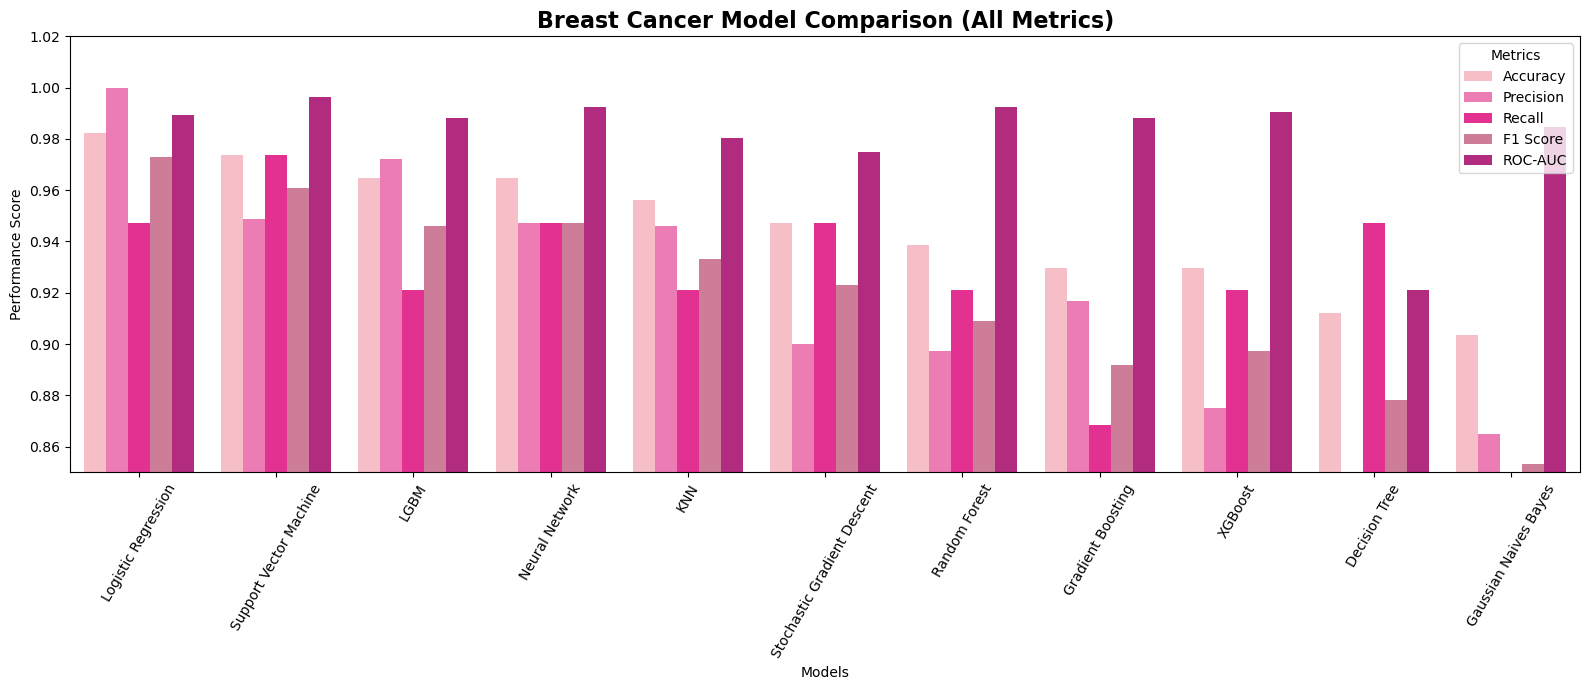

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert dataframe to long format
results_melted = results_df.melt(id_vars="Model",
                                 var_name="Metric",
                                 value_name="Score")

plt.figure(figsize=(16,7))

# Pink color palette
pink_palette = ["#FFB6C1", "#FF69B4", "#FF1493", "#DB7093", "#C71585"]

sns.barplot(data=results_melted,
            x="Model",
            y="Score",
            hue="Metric",
            palette=pink_palette)

plt.xticks(rotation=60)
plt.ylim(0.85, 1.02)

plt.title("Breast Cancer Model Comparison (All Metrics)",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Models")
plt.ylabel("Performance Score")

plt.legend(title="Metrics")
plt.tight_layout()
plt.show()


# Best Model SAVE

In [164]:
import pickle
from sklearn.svm import SVC

# Train Best Model
best_model = SVC(probability=True)
best_model.fit(X_train, y_train)

# Save Model
with open("breast_cancer_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("✅ Model Saved Successfully")


✅ Model Saved Successfully


In [166]:
import pickle
import os

# Define full path
file_path = os.path.join(os.getcwd(), "breast_cancer_model.pkl")

with open(file_path, "wb") as f:
    pickle.dump(best_model, f)

print("Saved at:", file_path)


Saved at: C:\Users\mohiv\Downloads\breast_cancer_model.pkl
